## 1. Configuração dos experimentos

In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline

## 2. Carregamento e preparação dos dados

In [23]:
RAIZ = next(
    pasta for pasta in [Path.cwd(), *Path.cwd().parents]
    if (pasta / 'dataset').is_dir()
)

dados = {}

for abordagem in ['abordagem_1', 'abordagem_2']:
    pasta = RAIZ / 'dataset' / abordagem

    treino = pd.read_csv(pasta / 'treino.csv')
    teste = pd.read_csv(pasta / 'teste.csv')
    validacao = pd.read_csv(pasta / 'validacao.csv')

    dados[abordagem] = {
        'treino': treino,
        'teste': teste,
        'validacao': validacao
    }

In [24]:
for abordagem in dados:
    treino = dados[abordagem]['treino']

    print(f'\n{abordagem.upper()}')
    print('Distribuição das classes no treinamento:')
    print(treino['classe'].value_counts())


ABORDAGEM_1
Distribuição das classes no treinamento:
classe
X venceu    140
Tem jogo    140
O venceu    140
Empate      140
Name: count, dtype: int64

ABORDAGEM_2
Distribuição das classes no treinamento:
classe
X venceu    140
Tem jogo    140
O venceu    140
Empate      140
Name: count, dtype: int64


## 3. Treinamento e validação da Random Forest

In [25]:
for abordagem in dados:
    treino = dados[abordagem]['treino']
    teste = dados[abordagem]['teste']
    validacao = dados[abordagem]['validacao']

    dados[abordagem]['x_treino'] = treino.drop(columns=['classe']).astype(int)
    dados[abordagem]['y_treino'] = treino['classe']

    dados[abordagem]['x_teste'] = teste.drop(columns=['classe']).astype(int)
    dados[abordagem]['y_teste'] = teste['classe']

    dados[abordagem]['x_validacao'] = validacao.drop(columns=['classe']).astype(int)
    dados[abordagem]['y_validacao'] = validacao['classe']

In [26]:
resultados = {}
modelos = {}
predicoes = {}
dados_modelos = {}

def avaliar(nome, modelo):

    for abordagem in ['abordagem_1', 'abordagem_2']:

        x_treino = dados[abordagem]['x_treino']
        y_treino = dados[abordagem]['y_treino']
        x_validacao = dados[abordagem]['x_validacao']
        y_validacao = dados[abordagem]['y_validacao']

        modelo_atual = Pipeline([
            ('rf', clone(modelo))
        ])

        modelo_atual.fit(x_treino, y_treino)
        y_pred = modelo_atual.predict(x_validacao)

        chave = f"{nome}_{abordagem.replace('abordagem_', 'ab')}"

        resultados[chave] = {
            'acuracia': accuracy_score(y_validacao, y_pred),
            'precisao': precision_score(
                y_validacao, y_pred, average='macro', zero_division=0
            ),
            'recall': recall_score(
                y_validacao, y_pred, average='macro', zero_division=0
            ),
            'f1': f1_score(
                y_validacao, y_pred, average='macro', zero_division=0
            ),
        }

        modelos[chave] = modelo_atual
        predicoes[chave] = y_pred
        dados_modelos[chave] = dados[abordagem]

        print(f"{chave} | F1 macro = {resultados[chave]['f1']:.4f}")

    return modelo_atual, y_pred

In [27]:
avaliar('rf_1',
        RandomForestClassifier(n_estimators=50,
                               class_weight='balanced',
                               random_state=42)
        )

rf_1_ab1 | F1 macro = 0.7026
rf_1_ab2 | F1 macro = 0.9747


(Pipeline(steps=[('rf',
                  RandomForestClassifier(class_weight='balanced',
                                         n_estimators=50, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X venceu

In [28]:
avaliar('rf_2',
        RandomForestClassifier(n_estimators=100,
                               class_weight='balanced',
                               random_state=42)
        )

rf_2_ab1 | F1 macro = 0.7267
rf_2_ab2 | F1 macro = 0.9747


(Pipeline(steps=[('rf',
                  RandomForestClassifier(class_weight='balanced',
                                         random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X venceu', 'X venceu', 'X

In [29]:
avaliar('rf_3',
        RandomForestClassifier(n_estimators=200,
                               class_weight='balanced',
                               random_state=42)
        )

rf_3_ab1 | F1 macro = 0.7180
rf_3_ab2 | F1 macro = 0.9747


(Pipeline(steps=[('rf',
                  RandomForestClassifier(class_weight='balanced',
                                         n_estimators=200, random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X vence

In [30]:
avaliar('rf_4',
        RandomForestClassifier(n_estimators=100,
                               max_depth=5,
                               class_weight='balanced',
                               random_state=42)
        )

rf_4_ab1 | F1 macro = 0.6500
rf_4_ab2 | F1 macro = 0.9176


(Pipeline(steps=[('rf',
                  RandomForestClassifier(class_weight='balanced', max_depth=5,
                                         random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'Empate', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X venceu', 'X 

In [31]:
avaliar('rf_5',
        RandomForestClassifier(n_estimators=100,
                               max_depth=10,
                               class_weight='balanced',
                               random_state=42)
        )

rf_5_ab1 | F1 macro = 0.7181
rf_5_ab2 | F1 macro = 0.9747


(Pipeline(steps=[('rf',
                  RandomForestClassifier(class_weight='balanced', max_depth=10,
                                         random_state=42))]),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X venceu', 

In [32]:
def graficos(nome, y_real, y_pred, conjunto):
    modelo = modelos[nome].named_steps['rf']
    rotulo = f"{nome} ({conjunto})"

    # 1) Matriz de confusão
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_real, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f"Matriz de confusão – {rotulo}")
    plt.show()

    # 2) Quantidade por classe: real vs predito
    classes = np.unique(np.concatenate([np.asarray(y_real), y_pred]))
    real = [np.sum(np.asarray(y_real) == c) for c in classes]
    pred = [np.sum(y_pred == c) for c in classes]
    x = np.arange(len(classes))

    plt.figure(figsize=(8, 5))
    plt.bar(x - 0.2, real, width=0.4, label="Real", color="blue", alpha=0.7)
    plt.bar(x + 0.2, pred, width=0.4, label="Predito", color="red", alpha=0.7)
    plt.xticks(x, classes)
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.title(f"Distribuição das classes – {rotulo}")
    plt.legend()
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.show()

    # 3) Importância dos atributos (casas do tabuleiro)
    importancias = pd.Series(modelo.feature_importances_, index=modelo.feature_names_in_).sort_values()
    plt.figure(figsize=(8, 5))
    plt.barh(importancias.index, importancias.values, color="green", alpha=0.7)
    plt.xlabel("Importância")
    plt.title(f"Importância das casas – {rotulo}")
    plt.grid(True, axis="x", linestyle="--", alpha=0.6)
    plt.show()

    # Relatório por classe
    print(f"Relatório – {rotulo}")
    print(classification_report(y_real, y_pred, zero_division=0))

    # Estrutura da floresta
    print("Número de árvores:", modelo.n_estimators)
    print("Profundidade máxima:", modelo.max_depth)
    profundidades = [arvore.get_depth() for arvore in modelo.estimators_]
    print("Profundidade média real das árvores:", np.mean(profundidades))

### 3.1 Justificativa dos parâmetros

- **n_estimators (50, 100 e 200)**: é o número de árvores da floresta. Mais árvores deixam a votação mais estável, mas a partir de certo ponto o ganho é pequeno e o custo de treino aumenta. Variar só esse parâmetro em rf_1, rf_2 e rf_3 mostra se vale a pena ter mais árvores.
- **max_depth (sem limite, 5 e 10)**: é a profundidade máxima de cada árvore. Sem limite, as árvores crescem até separar todo o treino, o que tende ao overfitting. Limitar a profundidade simplifica as árvores. rf_2, rf_4 e rf_5 têm 100 árvores e variam só a profundidade.
- **class_weight='balanced'**: dá a cada classe um peso inversamente proporcional à sua frequência, para o Empate não ser ignorado. É uma alternativa ao oversampling que não duplica dados.
random_state=42: fixa o sorteio das amostras e dos atributos de cada árvore, para os resultados serem reproduzíveis.
- **Sem normalização**: a Random Forest divide os dados por limiares em cada atributo, então a escala dos valores não muda o resultado. Por isso o StandardScaler usado no MLP não foi necessário.
- **Critério de escolha (F1-macro)**: o mesmo do MLP, para que os dois modelos sejam comparados com a mesma métrica.


### 3.2 Análise de overfitting

Análise de overfitting
          f1_treino  f1_validacao  diferenca
rf_1_ab1     1.0000        0.7026     0.2974
rf_1_ab2     0.9929        0.9747     0.0182
rf_2_ab1     1.0000        0.7267     0.2733
rf_2_ab2     0.9929        0.9747     0.0182
rf_3_ab1     1.0000        0.7180     0.2820
rf_3_ab2     0.9929        0.9747     0.0182
rf_4_ab1     0.8698        0.6500     0.2197
rf_4_ab2     0.9600        0.9176     0.0424
rf_5_ab1     1.0000        0.7181     0.2819
rf_5_ab2     0.9892        0.9747     0.0146


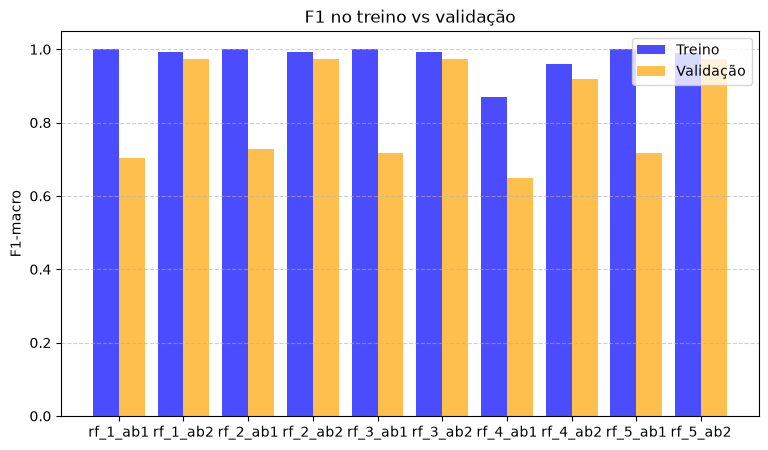

In [33]:
# F1 no treino vs F1 na validação
overfitting = {}
for nome, modelo in modelos.items():
    x_treino = dados_modelos[nome]['x_treino']
    y_treino = dados_modelos[nome]['y_treino']

    y_pred_treino = modelo.predict(x_treino)

    f1_treino = f1_score(y_treino, y_pred_treino, average='macro', zero_division=0)
    f1_val = resultados[nome]['f1']
    overfitting[nome] = {
        'f1_treino': f1_treino,
        'f1_validacao': f1_val,
        'diferenca': f1_treino - f1_val,
    }

df_overfitting = pd.DataFrame(overfitting).T.round(4)
print('Análise de overfitting')
print(df_overfitting)

# Gráfico: F1 treino vs validação
x = np.arange(len(df_overfitting))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, df_overfitting['f1_treino'], width=0.4, label="Treino", color="blue", alpha=0.7)
plt.bar(x + 0.2, df_overfitting['f1_validacao'], width=0.4, label="Validação", color="orange", alpha=0.7)
plt.xticks(x, df_overfitting.index)
plt.ylabel("F1-macro")
plt.ylim(0, 1.05)
plt.title("F1 no treino vs validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

### 3.3 Interpretação dos resultados de overfitting

- A diferença entre as abordagens é o achado principal. Na abordagem 1, o treino fica perto de 1,0 e a validação entre 0,65 e 0,73, uma diferença de quase 0,3, ou seja, overfitting forte. Na abordagem 2, treino e validação ficam próximos (cerca de 0,99 e 0,97), com pouco overfitting.
- O número de árvores quase não muda nada. rf_1, rf_2 e rf_3 têm resultados praticamente iguais. 50 árvores já bastam.
- **max_depth=5 causa underfitting**. O rf_4 é o único que não chega a 1,0 no treino, nas duas abordagens, e também tem a pior validação. Árvores rasas demais não capturam as regras do jogo.
- **max_depth=10 ficou muito próximo ao sem limite**. Observando a profundidade média real das árvores podemos ver que ela ficou em 13.18, logo o limite de 10 apresenta um resultado muito próximo do sem limite.

## 4. Resultados dos experimentos

### 4.1 Resultados na Validação

-----
Tabela de resultados
          acuracia  precisao  recall      f1
rf_1_ab2    0.9677    0.9763  0.9750  0.9747
rf_2_ab2    0.9677    0.9763  0.9750  0.9747
rf_5_ab2    0.9677    0.9763  0.9750  0.9747
rf_3_ab2    0.9677    0.9763  0.9750  0.9747
rf_4_ab2    0.9355    0.8998  0.9500  0.9176
rf_2_ab1    0.7957    0.8458  0.6917  0.7267
rf_5_ab1    0.7849    0.8382  0.6833  0.7181
rf_3_ab1    0.7849    0.8377  0.6833  0.7180
rf_1_ab1    0.7634    0.8228  0.6667  0.7026
rf_4_ab1    0.5914    0.6272  0.6833  0.6500
-----


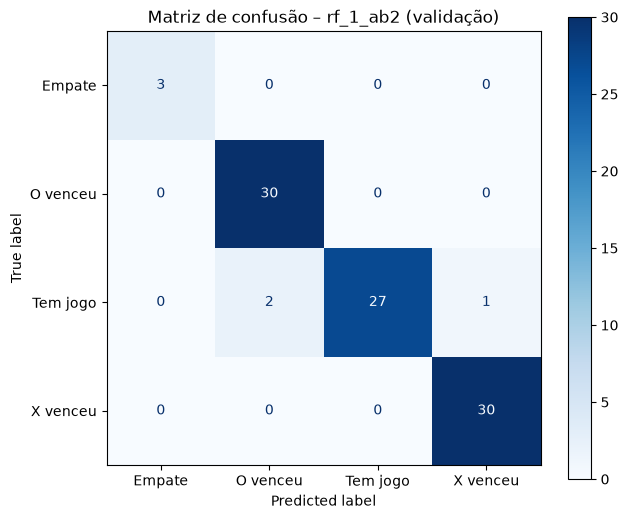

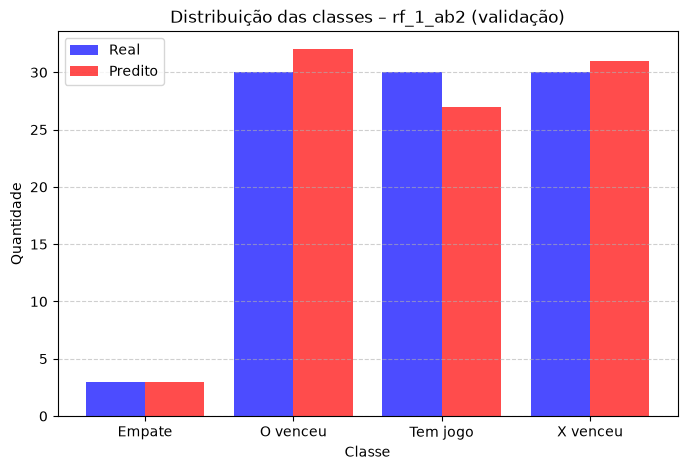

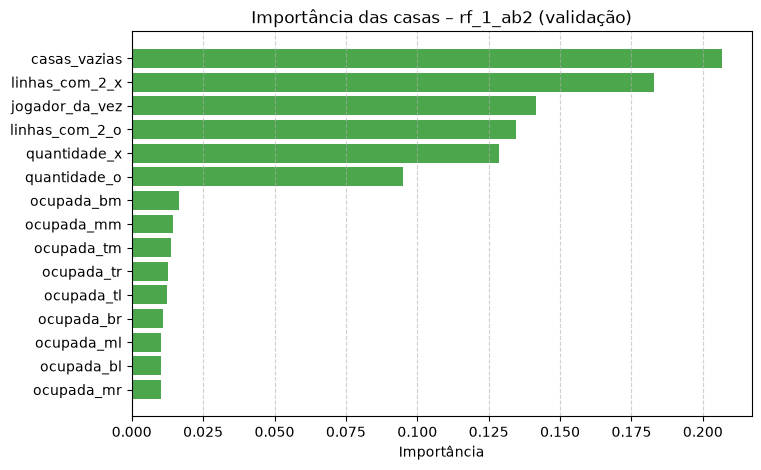

Relatório – rf_1_ab2 (validação)
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       0.94      1.00      0.97        30
    Tem jogo       1.00      0.90      0.95        30
    X venceu       0.97      1.00      0.98        30

    accuracy                           0.97        93
   macro avg       0.98      0.97      0.97        93
weighted avg       0.97      0.97      0.97        93

Número de árvores: 50
Profundidade máxima: None
Profundidade média real das árvores: 13.18


In [34]:
print("-----")
print('Tabela de resultados')
df = pd.DataFrame(resultados).T.round(4)
print(df.sort_values('f1', ascending=False))
print('-----')

melhor = df['f1'].idxmax()
y_validacao = dados_modelos[melhor]['y_validacao']
graficos(melhor, y_validacao, predicoes[melhor], 'validação')

### 4.2 Gráfico comparativo

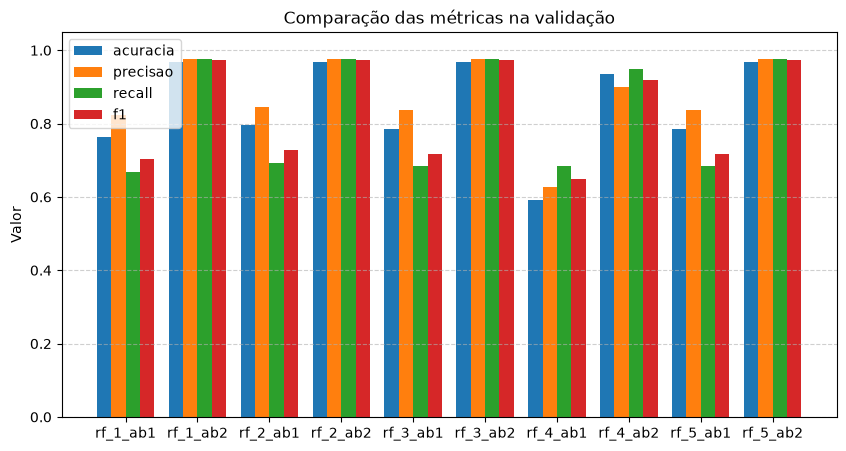

In [35]:
# Comparação das 4 métricas na validação para cada modelo
metricas = ['acuracia', 'precisao', 'recall', 'f1']
x = np.arange(len(df))
largura = 0.2

plt.figure(figsize=(10, 5))
for i, metrica in enumerate(metricas):
    plt.bar(x + (i - 1.5) * largura, df[metrica], width=largura, label=metrica)
plt.xticks(x, df.index)
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.title("Comparação das métricas na validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

### 4.3 Avaliação no conjunto de teste

-----
Resultado final no teste – rf_1_ab2
acuracia    0.9355
precisao    0.9583
recall      0.9500
f1          0.9495
dtype: float64
-----


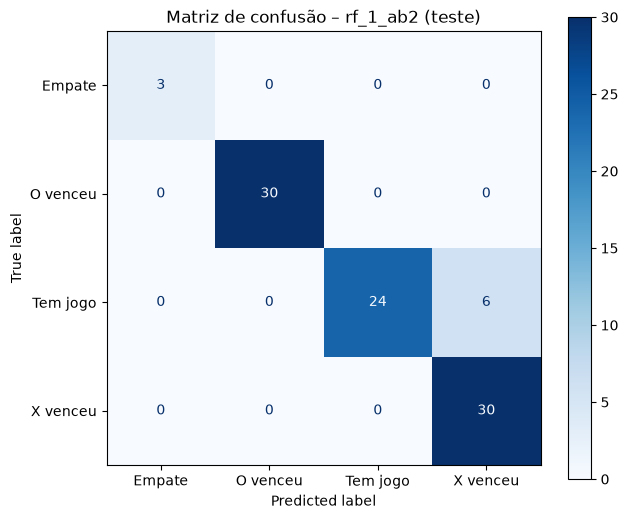

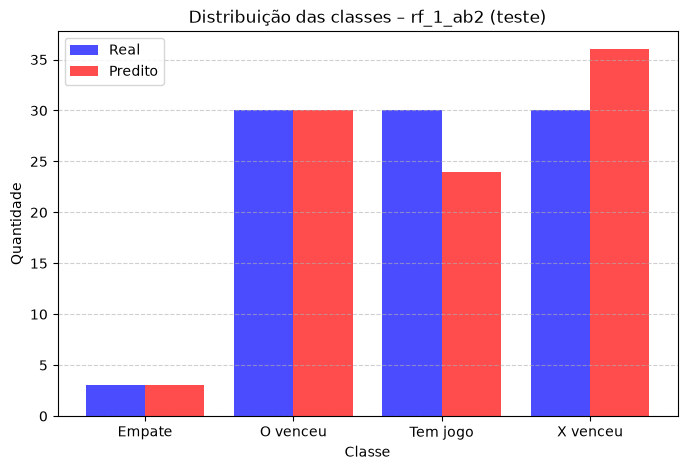

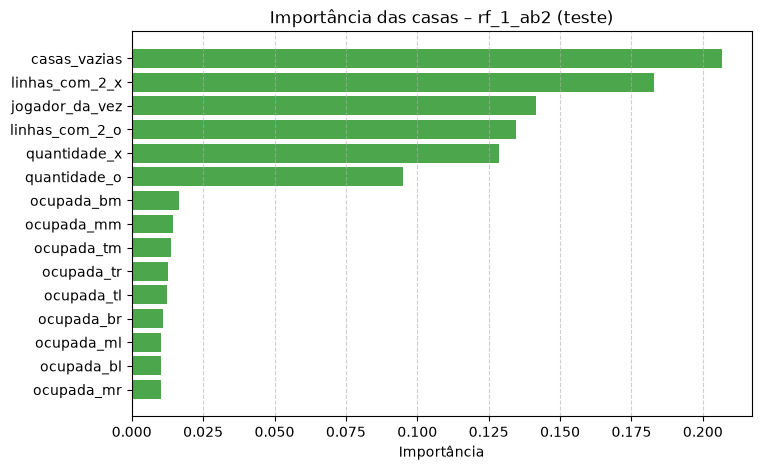

Relatório – rf_1_ab2 (teste)
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       1.00      1.00      1.00        30
    Tem jogo       1.00      0.80      0.89        30
    X venceu       0.83      1.00      0.91        30

    accuracy                           0.94        93
   macro avg       0.96      0.95      0.95        93
weighted avg       0.95      0.94      0.93        93

Número de árvores: 50
Profundidade máxima: None
Profundidade média real das árvores: 13.18


In [36]:
# Avaliação final no TESTE
modelo_final = modelos[melhor]

x_teste = dados_modelos[melhor]['x_teste']
y_teste = dados_modelos[melhor]['y_teste']

y_pred_teste = modelo_final.predict(x_teste)

resultado_teste = {
    'acuracia': accuracy_score(y_teste, y_pred_teste),
    'precisao': precision_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'recall':   recall_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'f1':       f1_score(y_teste, y_pred_teste, average='macro', zero_division=0),
}

print('-----')
print(f'Resultado final no teste – {melhor}')
print(pd.Series(resultado_teste).round(4))
print('-----')

graficos(melhor, y_teste, y_pred_teste, 'teste')

### 4.4 Análise dos resultados

- O F1-macro foi de 0,97 na validação para 0,95 no teste, e a acurácia de 0,97 para 0,94. Uma queda de 2 a 3 pontos é pequena, então o modelo generaliza bem e a validação foi um bom critério de escolha.
- O melhor foi o rf_1, com só 50 árvores. Como rf_1, rf_2 e rf_3 tiveram resultados praticamente iguais, mais árvores não trouxeram ganho. Se os F1 estiverem empatados na tabela, dá para argumentar que o modelo mais simples é preferível.
- Sobre a profundidade: a profundidade média real das árvores foi 13,18. O rf_5 (limitado a 10) cortou pouco e teve resultado parecido, então os níveis mais profundos acrescentam pouco. Já o limite de 5 cortou demais e causou underfitting.
- Ponto fraco: os erros se concentram em Tem jogo, confundido com vitórias, pela explicação das linhas com 2 peças que comentei antes.

## 5. Conclusão

Resultado final: a Random Forest com a abordagem 2 (rf_1, 50 árvores) teve F1-macro de 0,95 e acurácia de 0,94 no teste.
Principal conclusão: a abordagem de pré-processamento fez muito mais diferença que os hiperparâmetros. Com o tabuleiro cru, a validação ficou entre 0,65 e 0,73 e houve overfitting forte. Com os atributos derivados, ficou perto de 0,97. Variar o número de árvores praticamente não mudou nada.
Desbalanceamento: o class_weight='balanced' resolveu o Empate sem precisar duplicar dados, mas com tão poucos exemplos a confiança nesse resultado é limitada.